# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# ============================================================

# Batch **size**

# **16**

Device: cuda
Epoch 1/100 - Loss:192.0571 Train Acc:84.61% Val Acc:75.71% Train F1:0.8461 Val F1:0.7441
Epoch 2/100 - Loss:158.0023 Train Acc:88.86% Val Acc:92.78% Train F1:0.8885 Val F1:0.9277
Epoch 3/100 - Loss:139.1847 Train Acc:90.12% Val Acc:85.23% Train F1:0.9011 Val F1:0.8503
Epoch 4/100 - Loss:120.5584 Train Acc:91.48% Val Acc:64.22% Train F1:0.9148 Val F1:0.5926
Epoch 5/100 - Loss:113.4882 Train Acc:92.77% Val Acc:90.37% Train F1:0.9277 Val F1:0.9034
Epoch 6/100 - Loss:119.3538 Train Acc:92.09% Val Acc:76.91% Train F1:0.9209 Val F1:0.7593
Epoch 7/100 - Loss:113.2192 Train Acc:91.87% Val Acc:92.89% Train F1:0.9186 Val F1:0.9288
Epoch 8/100 - Loss:108.4980 Train Acc:92.96% Val Acc:82.49% Train F1:0.9296 Val F1:0.8201
Epoch 9/100 - Loss:95.8096 Train Acc:93.92% Val Acc:66.96% Train F1:0.9392 Val F1:0.6359
Epoch 10/100 - Loss:104.0515 Train Acc:93.13% Val Acc:93.00% Train F1:0.9313 Val F1:0.9299
Epoch 11/100 - Loss:91.1355 Train Acc:94.63% Val Acc:92.01% Train F1:0.9463 Val F1:0.91

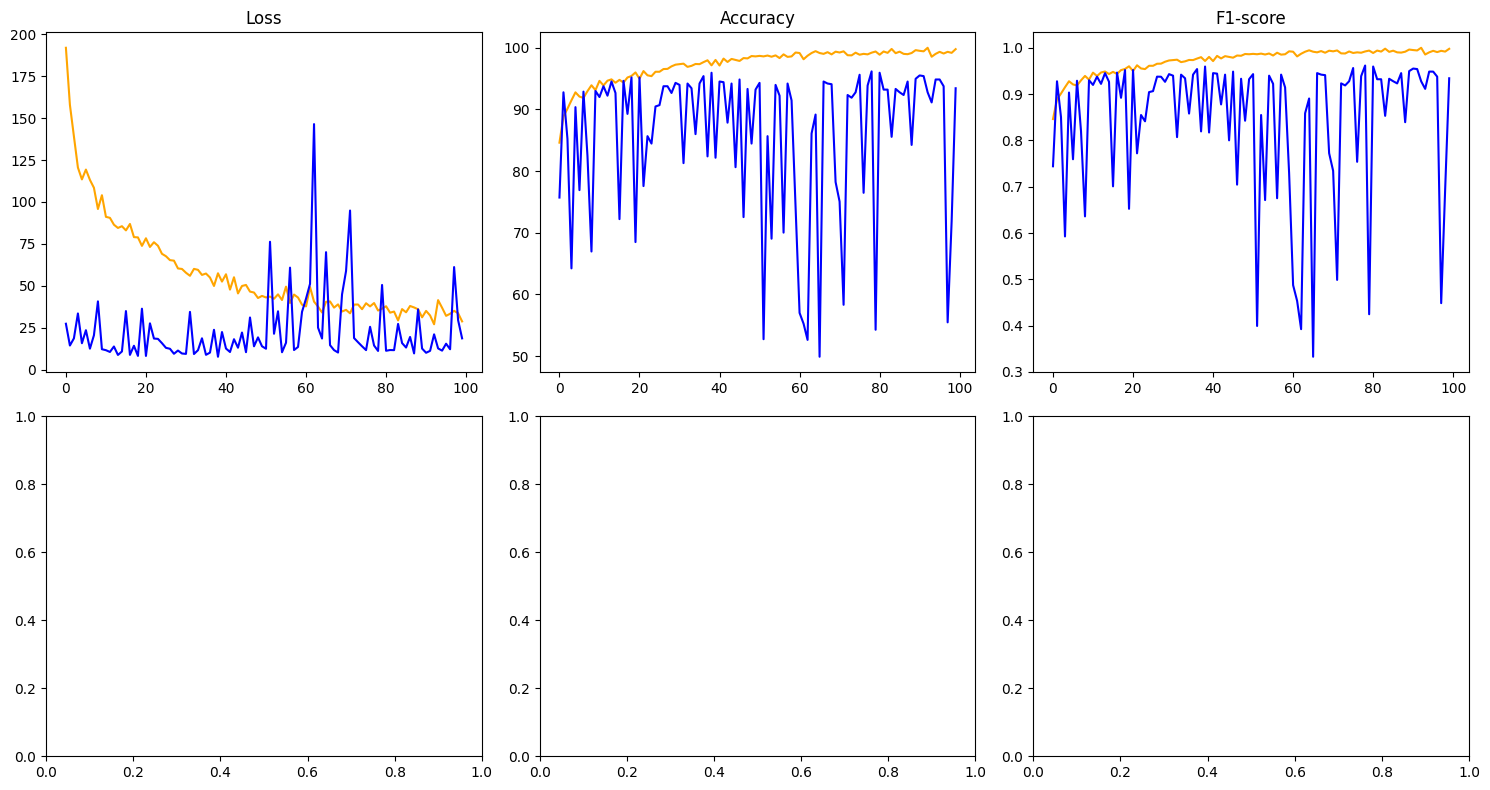

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Train/Validation + ROC + PR + IEEE Figures
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=16, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()

## **64**

Device: cuda
Epoch 1/100 - Loss:51.3850 Train Acc:83.71% Val Acc:72.98% Train F1:0.8371 Val F1:0.7123
Epoch 2/100 - Loss:42.8682 Train Acc:88.53% Val Acc:84.57% Train F1:0.8852 Val F1:0.8437
Epoch 3/100 - Loss:37.2227 Train Acc:90.85% Val Acc:88.29% Train F1:0.9085 Val F1:0.8824
Epoch 4/100 - Loss:34.5384 Train Acc:92.25% Val Acc:90.04% Train F1:0.9225 Val F1:0.9004
Epoch 5/100 - Loss:33.3923 Train Acc:91.76% Val Acc:91.58% Train F1:0.9176 Val F1:0.9158
Epoch 6/100 - Loss:31.5339 Train Acc:92.61% Val Acc:86.32% Train F1:0.9261 Val F1:0.8618
Epoch 7/100 - Loss:32.3067 Train Acc:91.76% Val Acc:77.02% Train F1:0.9176 Val F1:0.7587
Epoch 8/100 - Loss:28.1358 Train Acc:93.78% Val Acc:89.61% Train F1:0.9378 Val F1:0.8960
Epoch 9/100 - Loss:27.0635 Train Acc:93.48% Val Acc:93.54% Train F1:0.9348 Val F1:0.9354
Epoch 10/100 - Loss:25.9919 Train Acc:94.19% Val Acc:91.58% Train F1:0.9419 Val F1:0.9157
Epoch 11/100 - Loss:25.3029 Train Acc:94.66% Val Acc:84.68% Train F1:0.9466 Val F1:0.8442
Epoch 

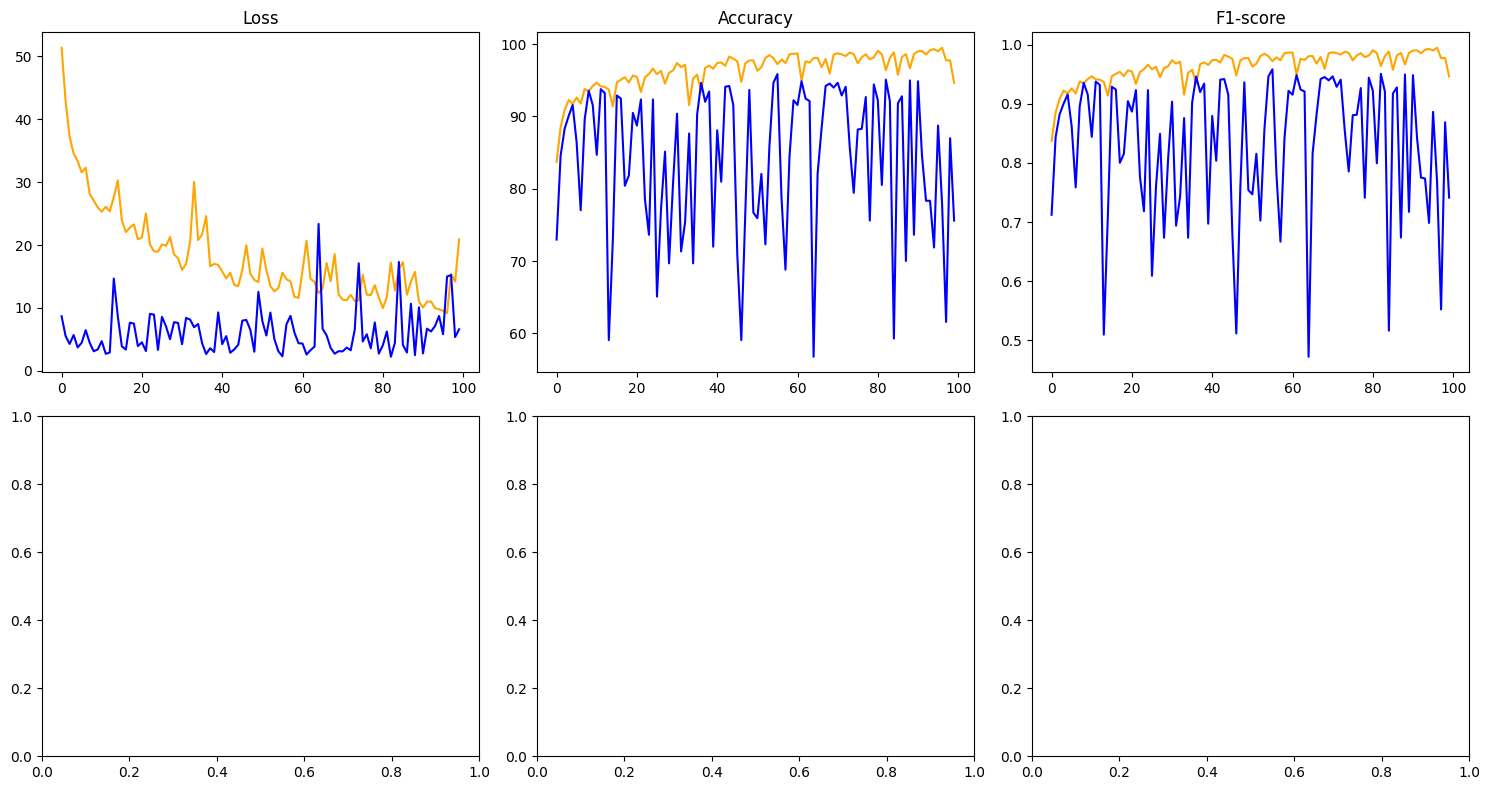

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Train/Validation + ROC + PR + IEEE Figures
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=64, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()

# **128**

Device: cuda
Epoch 1/100 - Loss:27.1678 Train Acc:81.46% Val Acc:52.52% Train F1:0.8146 Val F1:0.3886
Epoch 2/100 - Loss:25.1418 Train Acc:85.30% Val Acc:53.39% Train F1:0.8530 Val F1:0.4061
Epoch 3/100 - Loss:21.5466 Train Acc:89.18% Val Acc:75.71% Train F1:0.8918 Val F1:0.7441
Epoch 4/100 - Loss:18.6939 Train Acc:92.03% Val Acc:56.67% Train F1:0.9203 Val F1:0.4666
Epoch 5/100 - Loss:18.5615 Train Acc:91.62% Val Acc:82.71% Train F1:0.9162 Val F1:0.8232
Epoch 6/100 - Loss:16.8165 Train Acc:93.57% Val Acc:58.32% Train F1:0.9356 Val F1:0.4977
Epoch 7/100 - Loss:15.5405 Train Acc:94.44% Val Acc:71.33% Train F1:0.9444 Val F1:0.6894
Epoch 8/100 - Loss:15.1216 Train Acc:94.36% Val Acc:58.64% Train F1:0.9436 Val F1:0.5033
Epoch 9/100 - Loss:16.2140 Train Acc:93.04% Val Acc:69.47% Train F1:0.9304 Val F1:0.6653
Epoch 10/100 - Loss:14.9389 Train Acc:93.76% Val Acc:91.68% Train F1:0.9376 Val F1:0.9168
Epoch 11/100 - Loss:14.1711 Train Acc:94.44% Val Acc:89.28% Train F1:0.9444 Val F1:0.8922
Epoch 

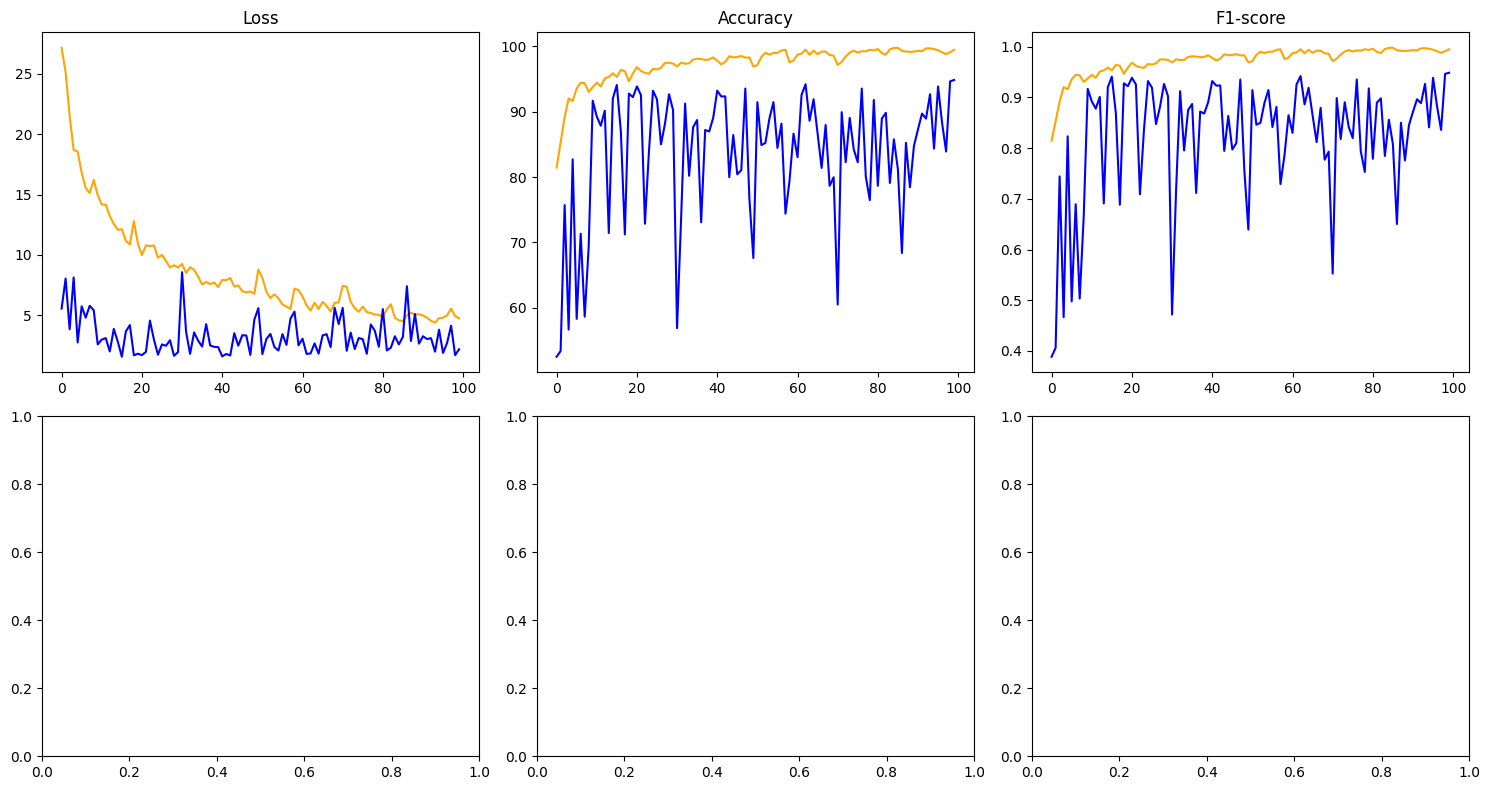

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Train/Validation + ROC + PR + IEEE Figures
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=128, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=128, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()

# **256**

Device: cuda
Epoch 1/100 - Loss:15.2774 Train Acc:76.51% Val Acc:57.33% Train F1:0.7650 Val F1:0.4841
Epoch 2/100 - Loss:12.3975 Train Acc:85.93% Val Acc:74.07% Train F1:0.8592 Val F1:0.7267
Epoch 3/100 - Loss:11.4998 Train Acc:88.09% Val Acc:79.65% Train F1:0.8808 Val F1:0.7899
Epoch 4/100 - Loss:11.4687 Train Acc:86.20% Val Acc:86.32% Train F1:0.8620 Val F1:0.8632
Epoch 5/100 - Loss:10.0768 Train Acc:90.25% Val Acc:86.54% Train F1:0.9025 Val F1:0.8644
Epoch 6/100 - Loss:9.5779 Train Acc:91.48% Val Acc:87.53% Train F1:0.9148 Val F1:0.8741
Epoch 7/100 - Loss:8.9418 Train Acc:92.91% Val Acc:82.60% Train F1:0.9291 Val F1:0.8225
Epoch 8/100 - Loss:8.8166 Train Acc:92.77% Val Acc:68.60% Train F1:0.9277 Val F1:0.6552
Epoch 9/100 - Loss:8.7080 Train Acc:92.44% Val Acc:78.01% Train F1:0.9244 Val F1:0.7715
Epoch 10/100 - Loss:8.7633 Train Acc:91.87% Val Acc:79.10% Train F1:0.9186 Val F1:0.7836
Epoch 11/100 - Loss:7.9545 Train Acc:93.46% Val Acc:82.17% Train F1:0.9346 Val F1:0.8169
Epoch 12/100

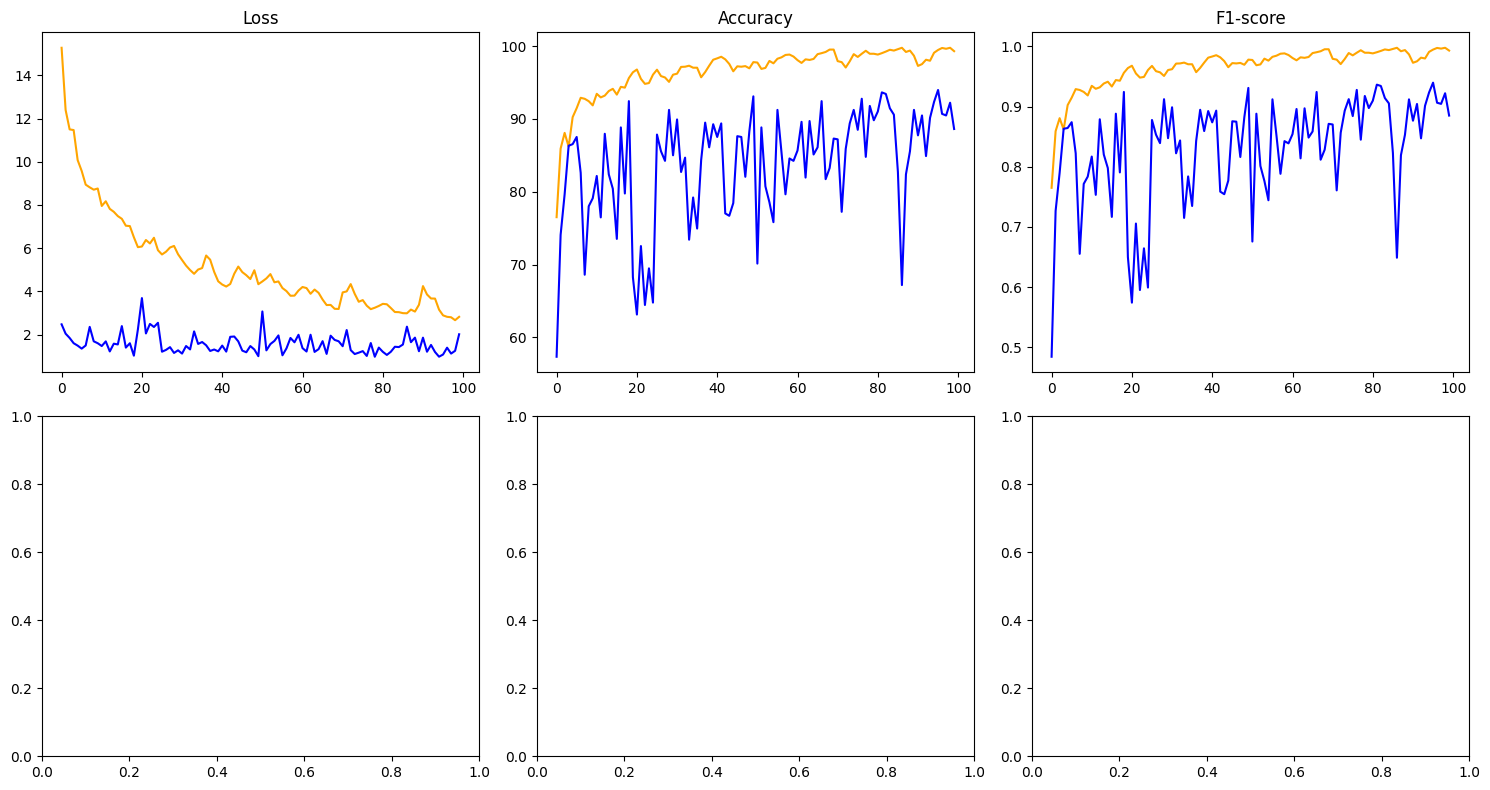

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Train/Validation + ROC + PR + IEEE Figures
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=256, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.conv3 = nn.Conv1d(64, 128, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(32)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(128)

        self.att1 = Attention1D(32)
        self.att2 = Attention1D(64)
        self.att3 = Attention1D(128)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(128)

        self.ds1 = nn.Linear(32, num_classes)
        self.ds2 = nn.Linear(64, num_classes)
        self.ds3 = nn.Linear(128, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x)))))
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1)))))
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2)))))

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()